In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
# ============================================
# 1. CHARGEMENT DES DONNÉES
# ============================================
df = pd.read_csv('../data/ObesityDataSet.csv')
print(df.shape)
print(df.head())


(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

In [6]:
# ============================================
# 2. VALEURS MANQUANTES
# ============================================
print("Valeurs manquantes")
print(df.isnull().sum())
print(f"\nTotal : {df.isnull().sum().sum()} valeurs manquantes")

Valeurs manquantes
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Total : 0 valeurs manquantes


In [7]:
# ============================================
# 3. INFOS GÉNÉRALES
# ============================================
print("Infos générales")
df.info()
print("\nStatistiques descriptives")
print(df.describe())
 

Infos générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF               

=== Distribution des classes ===
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

En pourcentage :
NObeyesdad
Obesity_Type_I         16.6
Obesity_Type_III       15.3
Obesity_Type_II        14.1
Overweight_Level_I     13.7
Overweight_Level_II    13.7
Normal_Weight          13.6
Insufficient_Weight    12.9
Name: proportion, dtype: float64


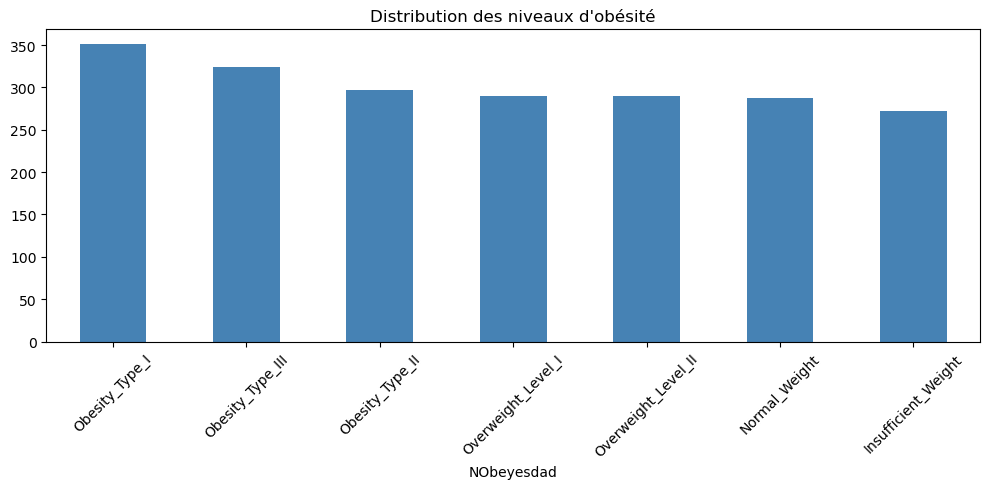

In [8]:
# ============================================
# 4. DISTRIBUTION DES CLASSES
# ============================================
print("=== Distribution des classes ===")
print(df['NObeyesdad'].value_counts())
print("\nEn pourcentage :")
print(df['NObeyesdad'].value_counts(normalize=True).round(3) * 100)
 
plt.figure(figsize=(10, 5))
df['NObeyesdad'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Distribution des niveaux d'obésité")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

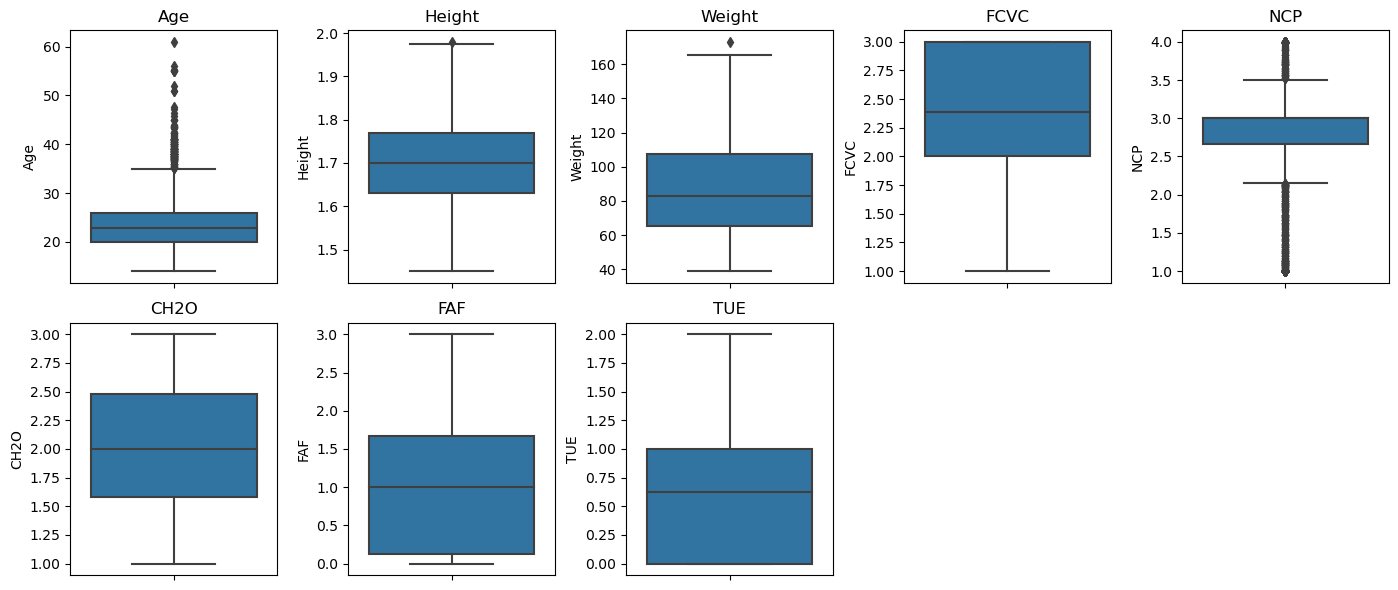

In [9]:
# ============================================
# 5. BOXPLOTS DES COLONNES NUMÉRIQUES
# ============================================
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
 
plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, len(numerical_cols)//2 + 1, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# 7. DOUBLONS
# ============================================
print(f"Nombre de doublons : {df.duplicated().sum()}")
print(df[df.duplicated()])
 
df = df.drop_duplicates()
print(f"Shape après suppression : {df.shape}")
print(f"Doublons restants : {df.duplicated().sum()}")
print("Doublons supprimés !")

Nombre de doublons : 24
     Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
98   Female  21.0    1.52    42.0                             no   no   3.0   
106  Female  25.0    1.57    55.0                             no  yes   2.0   
174    Male  21.0    1.62    70.0                             no  yes   2.0   
179    Male  21.0    1.62    70.0                             no  yes   2.0   
184    Male  21.0    1.62    70.0                             no  yes   2.0   
209  Female  22.0    1.69    65.0                            yes  yes   2.0   
309  Female  16.0    1.66    58.0                             no   no   2.0   
460  Female  18.0    1.62    55.0                            yes  yes   2.0   
467    Male  22.0    1.74    75.0                            yes  yes   3.0   
496    Male  18.0    1.72    53.0                            yes  yes   2.0   
527  Female  21.0    1.52    42.0                             no  yes   3.0   
659  Female  21.0    1.52   

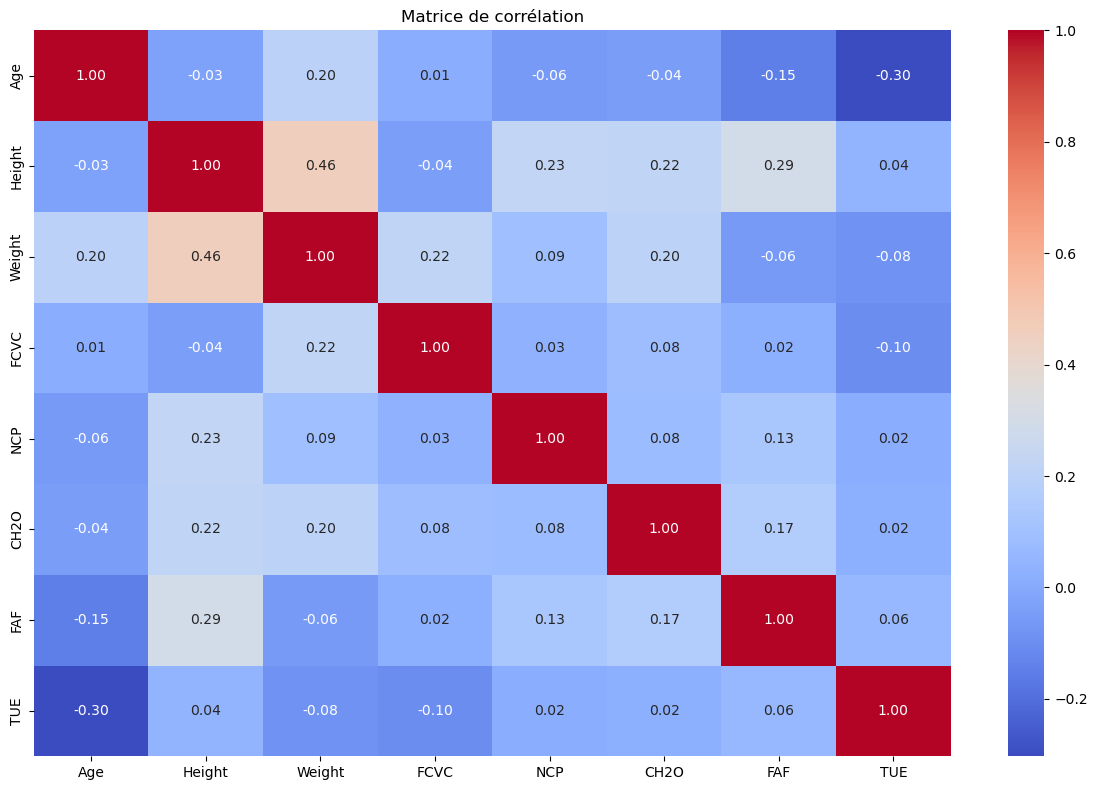


Fichier sauvegardé : DatasetObesity_cleaned.csv
Dimensions finales : (2087, 17)


In [11]:
# ============================================
# 8. MATRICE DE CORRÉLATION
# ============================================
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include=['float64', 'int64']).corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()
 
# ============================================
# 9. SAUVEGARDER LES DONNÉES NETTOYÉES
# ============================================
df.to_csv('DatasetObesity_cleaned.csv', index=False)
print(f"\nFichier sauvegardé : DatasetObesity_cleaned.csv")
print(f"Dimensions finales : {df.shape}")